In [2]:
import matplotlib.pyplot as plt
import numpy as np

from mpl_toolkits.basemap import Basemap

import xarray as xr
import pandas as pd
import cmocean
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.colors as colors

from mpl_toolkits.axes_grid1 import AxesGrid
from mpl_toolkits.basemap import Basemap

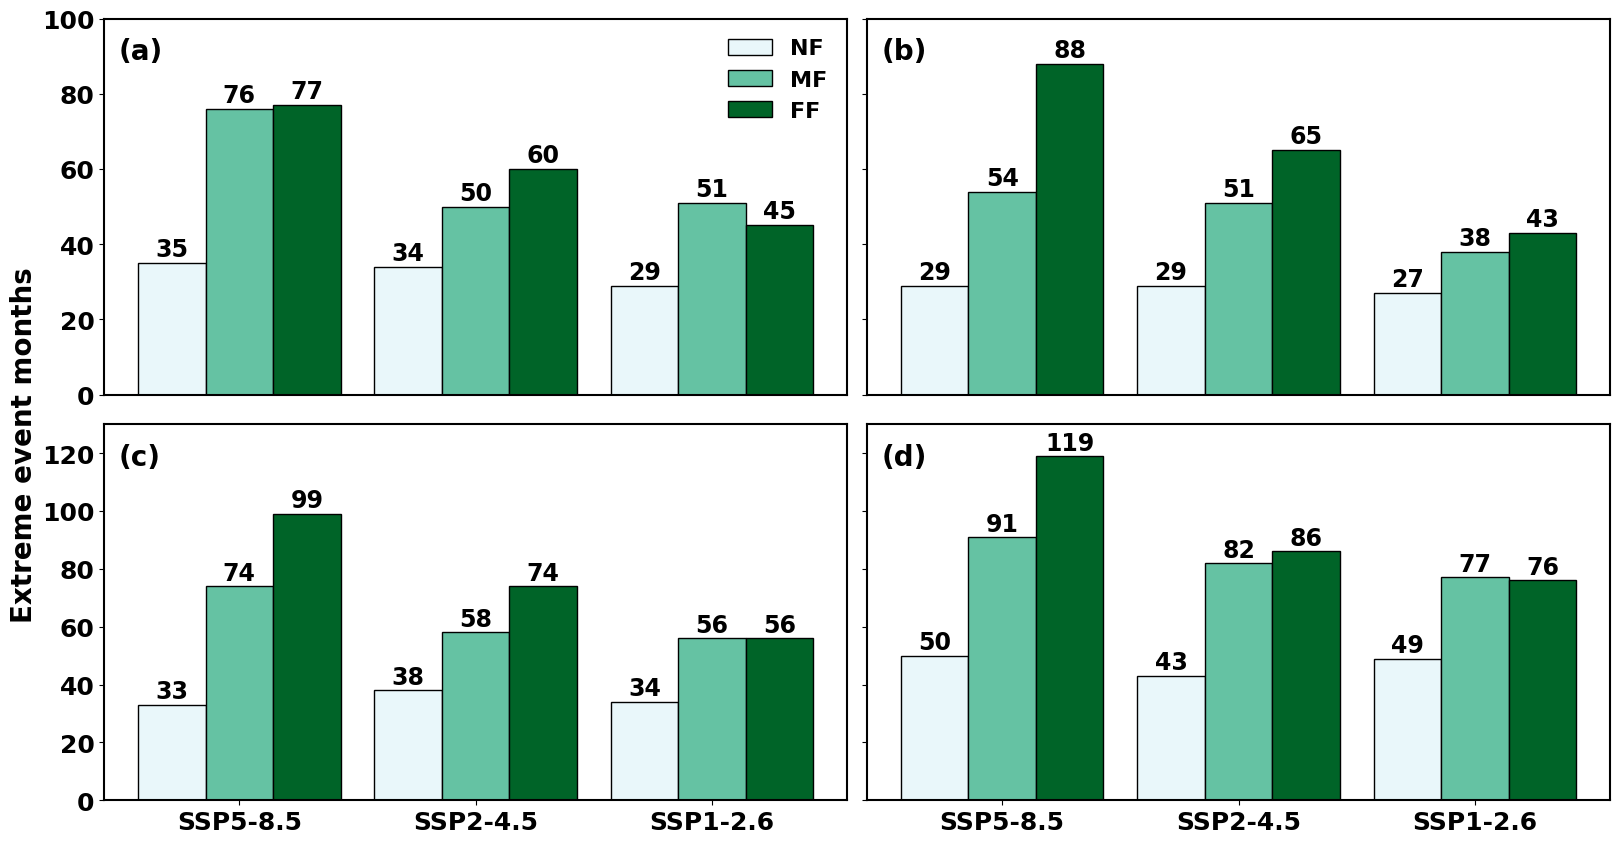

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# -----------------------------
# Global style
# -----------------------------
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

# -----------------------------
# Data
# -----------------------------
scenarios = ['SSP5-8.5', 'SSP2-4.5', 'SSP1-2.6']
periods   = ['NF', 'MF', 'FF']

# -----------------------------
# Rainbow colormap
# -----------------------------
cmap = plt.get_cmap('BuGn')
color_list = cmap(np.linspace(0.1, 0.9, 3))
colors = dict(zip(periods, color_list))

data = {
    'AS': {
        'SSP5-8.5': [35, 76, 77],
        'SSP2-4.5': [34, 50, 60],
        'SSP1-2.6': [29, 51, 45]
    },
    'BOB': {
        'SSP5-8.5': [29, 54, 88],
        'SSP2-4.5': [29, 51, 65],
        'SSP1-2.6': [27, 38, 43]
    },
    'EIO': {
        'SSP5-8.5': [33, 74, 99],
        'SSP2-4.5': [38, 58, 74],
        'SSP1-2.6': [34, 56, 56]
    },
    'SIO': {
        'SSP5-8.5': [50, 91, 119],
        'SSP2-4.5': [43, 82, 86],
        'SSP1-2.6': [49, 77, 76]
    }
}

panel_labels = ['(a)', '(b)', '(c)', '(d)']

# -----------------------------
# Plot setup
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(17, 9))
axes = axes.flatten()

bar_width = 0.2
x = np.array([0.0, 0.7, 1.4])

# -----------------------------
# Plot
# -----------------------------
for idx, (ax, (region, region_data)) in enumerate(zip(axes, data.items())):

    row = idx // 2
    col = idx % 2

    for i, period in enumerate(periods):
        values = [region_data[sc][i] for sc in scenarios]

        bars = ax.bar(
            x + i * bar_width,
            values,
            width=bar_width,
            color=colors[period],
            edgecolor='black',
            linewidth=1.0,
            label=period
        )

        for bar in bars:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.5,
                f'{int(h)}',
                ha='center',
                va='bottom',
                fontsize=17,
                fontweight='bold'
            )

    ax.text(
        0.02, 0.95,
        panel_labels[idx],
        transform=ax.transAxes,
        fontsize=20,
        fontweight='bold',
        va='top'
    )

    if idx < 2:
        ax.set_ylim(0, 100)
        ax.set_yticks(np.arange(0, 101, 20))
    else:
        ax.set_ylim(0, 130)
        ax.set_yticks(np.arange(0, 131, 20))

    if col == 0:
        ax.tick_params(axis='y', labelsize=18)
    else:
        ax.tick_params(axis='y', labelleft=False)

    if row == 1:
        ax.set_xticks(x + bar_width)
        ax.set_xticklabels(scenarios, fontsize=18, fontweight='bold')
    else:
        ax.set_xticks([])

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

# -----------------------------
# Common label & legend
# -----------------------------
fig.text(
    0.05, 0.5,
    'Extreme event months',
    va='center',
    rotation='vertical',
    fontsize=20,
    fontweight='bold'
)

axes[0].legend(fontsize=16, frameon=False)

plt.tight_layout(rect=[0.06, 0.05, 1, 1])
plt.savefig("extreme_events_cmip6_r1.png", dpi=300, bbox_inches="tight")
plt.show()